In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

In [2]:
# imputationproblem
N = 100
D=2

# generate data from multivari synthetica data where 5O% of the data is missing
np.random.seed(143)  # For reproducibility
X = np.random.multivariate_normal(mean=[0, 0], cov=[[1, 0.5], [0.5, 1]], size=N)

print(X.shape)

dataframe = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
dataframe.head()


(100, 2)


,Feature1,Feature2
0,0.102687,1.340378
1,2.663361,1.624731
2,-0.950500,-0.772275
3,0.644600,0.202511
4,0.452223,-0.016424


In [3]:
# mask 50% of the data
np.random.seed(143)  # For reproducibility
mask = np.random.rand(*X.shape) < 0.5
print(mask.shape)
print(mask[:5])  # Print the first 5 rows of the mask to verify
X_missing = X.copy()
X_missing[mask] = np.nan   
#remove the rows with all missing values
rows_with_all_missing = np.all(np.isnan(X_missing), axis=1)
X_missing = X_missing[~rows_with_all_missing]
#remove the same rows from the original data
X = X[~rows_with_all_missing]
print(X[:5])  # Print the first 5 rows of the original data to verify
print(X.shape)
print(X_missing.shape)
dataframe_missing = pd.DataFrame(X_missing, columns=['Feature1', 'Feature2'])
dataframe_missing.head()

(100, 2)
[[False  True]
 [ True  True]
 [False False]
 [ True  True]
 [ True  True]]
[[ 0.10268732  1.34037833]
 [-0.95050017 -0.77227524]
 [ 0.49763133  0.66907322]
 [ 0.48005185  0.23763652]
 [ 0.43685813  0.6935674 ]]
(72, 2)
(72, 2)


,Feature1,Feature2
0,0.102687,NaN
1,-0.950500,-0.772275
2,0.497631,NaN
3,0.480052,NaN
4,0.436858,NaN


In [4]:
# initialization of parameters, here it is mean and covariance matrix
# we want to compute the mean, covariance matrix using only the observed data
# remove the rows with missing values

mean = np.nanmean(X_missing, axis=0) # np.nan replaces the nan values with 0, and then computes the mean along the columns (axis=0), so its like computing mean of observed data only


observed_data = X_missing[~np.isnan(X_missing).any(axis=1)]
print(observed_data.shape)
print(observed_data[:5])  # Print the first 5 rows of the observed data to verify
cov = np.cov(observed_data, rowvar=False)

print("Initial Mean:", mean)
print("Initial Covariance Matrix:\n", cov)


(25, 2)
[[-0.95050017 -0.77227524]
 [ 0.38631888  0.90606477]
 [-0.22206186  0.08289809]
 [-3.23170745 -0.25497288]
 [ 1.64921196 -0.16488983]]
Initial Mean: [-0.08847933 -0.25223922]
Initial Covariance Matrix:
 [[1.27590175 0.27730632]
 [0.27730632 0.75510736]]


In [5]:
import numpy as np


def em_gaussian_missing_data(X_missing, mean, cov,max_iter=100, tol=1e-6):
    N, D = X_missing.shape
    
    # --- 1. Initialization ---
    # Initialize mean with the column means of observed data
    mu = mean.copy()
    cov = cov.copy()
    
    prev_ll = -np.inf
    
    for iteration in range(max_iter):
        sum_Ey = np.zeros(D)
        sum_EyyT = np.zeros((D, D))
        current_ll = 0
        
        # --- 2. E-Step ---
        for i in range(N):
            x_i = X_missing[i]
            observed = ~np.isnan(x_i)
            # if there are no observed values, we cannot update parameters based on this sample
            if not np.any(observed):
                continue

            missing = np.isnan(x_i)
            
            x_obs = x_i[observed]
            
            if missing.any():
                # Partitioning
                mu_h, mu_v = mu[missing], mu[observed]
                sigma_hh = cov[np.ix_(missing, missing)]
                sigma_hv = cov[np.ix_(missing, observed)]
                sigma_vv = cov[np.ix_(observed, observed)]
                sigma_vh = sigma_hv.T
                
                # Conditional distribution: p(z|x)
                inv_vv = np.linalg.inv(sigma_vv)
                gain = sigma_hv @ inv_vv
                
                m_n = mu_h + gain @ (x_obs - mu_v)
                v_n = sigma_hh - gain @ sigma_vh
                
                # Sufficient Statistics for this sample
                # reindexing to match the original order of features
                ''' (m_n; x_n) = temporary block vector: missing values replaced by expected values, observed values kept as-is.

                    Block order depends on which variable is missing.

                    Before summing to update μ, you reorder back to original variable order (f1, f2) so all rows are consistent.'''
                E_yn = np.zeros(D)
                E_yn[observed] = x_obs
                E_yn[missing] = m_n
                
                E_yynT = np.zeros((D, D))
                E_yynT[np.ix_(missing, missing)] = np.outer(m_n, m_n) + v_n
                E_yynT[np.ix_(observed, observed)] = np.outer(x_obs, x_obs)
                E_yynT[np.ix_(missing, observed)] = np.outer(m_n, x_obs)
                E_yynT[np.ix_(observed, missing)] = np.outer(x_obs, m_n)
                
                # Log-likelihood contribution (Marginal)
                current_ll += multivariate_normal.logpdf(x_obs, mean=mu_v, cov=sigma_vv)
            else:
                E_yn = x_i
                E_yynT = np.outer(x_i, x_i)
                current_ll += multivariate_normal.logpdf(x_i, mean=mu, cov=cov)
            
            sum_Ey += E_yn
            sum_EyyT += E_yynT
        
        # --- 3. M-Step ---
        mu = sum_Ey / N
        cov = (sum_EyyT / N) - np.outer(mu, mu)
        
        # Regularization to ensure positive semi-definite
        cov += np.eye(D) * 1e-6
        
        # --- 4. Convergence Check ---
        if abs(current_ll - prev_ll) < tol:
            print(f"Converged at iteration {iteration}")
            break
        prev_ll = current_ll
        
    return mu, cov

# Example usage:
mu_est, cov_est = em_gaussian_missing_data(X_missing, mean, cov)
print("Estimated Mean:", mu_est)
print("Estimated Covariance Matrix:\n", cov_est)


Converged at iteration 12
Estimated Mean: [-0.11459833 -0.22873258]
Estimated Covariance Matrix:
 [[1.00780523 0.21175057]
 [0.21175057 0.82783446]]


In [6]:
# impute now using the estimated parameters
def impute_missing_data(X_missing, mu, cov):
    N, D = X_missing.shape
    X_imputed = X_missing.copy()
    
    for i in range(N):
        x_i = X_missing[i]
        observed = ~np.isnan(x_i)
        # If there are no observed values, we cannot impute, so we skip this sample
        if not np.any(observed):
            continue
        
        missing = np.isnan(x_i)
        
        x_obs = x_i[observed]
        
        if missing.any():
            # Partitioning
            mu_h, mu_v = mu[missing], mu[observed]
            sigma_hh = cov[np.ix_(missing, missing)]
            sigma_hv = cov[np.ix_(missing, observed)]
            sigma_vv = cov[np.ix_(observed, observed)]
            sigma_vh = sigma_hv.T
            
            # Conditional distribution: p(z|x)
            inv_vv = np.linalg.inv(sigma_vv)
            gain = sigma_hv @ inv_vv
            
            m_n = mu_h + gain @ (x_obs - mu_v)
            
            # Impute missing values with conditional mean
            X_imputed[i, missing] = m_n
    
    return X_imputed

X_imputed = impute_missing_data(X_missing, mu_est, cov_est)
print("Imputed Data (first 5 rows):\n", X_imputed[:5])

# Now we can compare the imputed data with the original data (X) to see how well the EM algorithm performed in estimating the missing values.
# We can compute the mean squared error (MSE) between the imputed values and the original values for the missing entries.
mse = np.nanmean((X_imputed - X) ** 2)
print("Mean Squared Error between imputed and original data:", mse)    

Imputed Data (first 5 rows):
 [[ 0.10268732 -0.18307856]
 [-0.95050017 -0.77227524]
 [ 0.49763133 -0.10009664]
 [ 0.48005185 -0.10379027]
 [ 0.43685813 -0.11286573]]
Mean Squared Error between imputed and original data: 0.2546547287040568


In [7]:
#compute mean of the imputed data
imputed_mean = np.mean(X_imputed, axis=0)
print("Mean of Imputed Data:", imputed_mean)

#compute covariance of the imputed data
imputed_cov = np.cov(X_imputed, rowvar=False)
print("Covariance Matrix of Imputed Data:\n", imputed_cov)

Mean of Imputed Data: [-0.11458706 -0.22874459]
Covariance Matrix of Imputed Data:
 [[0.75336361 0.21469439]
 [0.21469439 0.54160562]]


In [8]:
# i need to check mse is less than the variance of the original data to confirm that imputation is better than just using the mean
original_variance = np.var(X, axis=0)
print("Variance of Original Data:", original_variance)

mse_less_than_variance = mse < original_variance
print("Is MSE less than the variance of the original data?", mse_less_than_variance)

Variance of Original Data: [1.00193138 0.8684628 ]
Is MSE less than the variance of the original data? [ True  True]


In [9]:
# impute missing data using mean imputation for comparison
X_mean_imputed = X_missing.copy()
col_means = np.nanmean(X_mean_imputed, axis=0)
inds = np.where(np.isnan(X_mean_imputed))
X_mean_imputed[inds] = np.take(col_means, inds[1])

#compute MSE for mean imputation
mse_mean = np.mean((X_mean_imputed - X)**2)
print("MSE for Mean Imputation:", mse_mean)

MSE for Mean Imputation: 0.31952989140678795


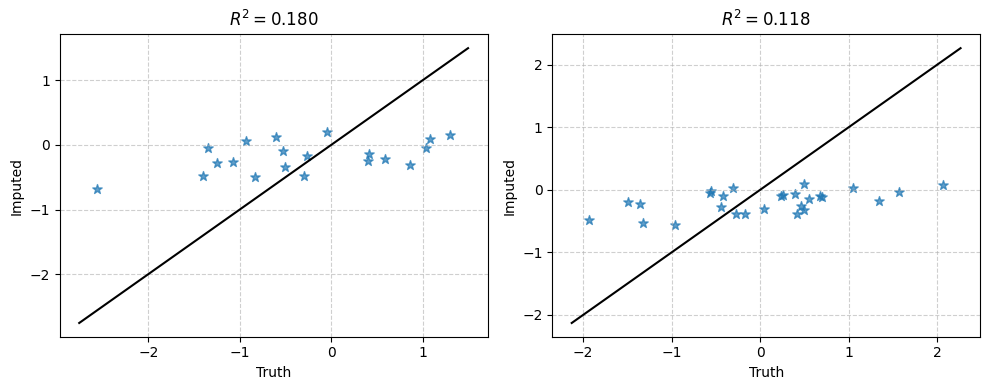

Imputed Data using True Parameters (first 5 rows):
 [[ 0.10268732  0.05134366]
 [-0.95050017 -0.77227524]
 [ 0.49763133  0.24881566]
 [ 0.48005185  0.24002593]
 [ 0.43685813  0.21842906]]


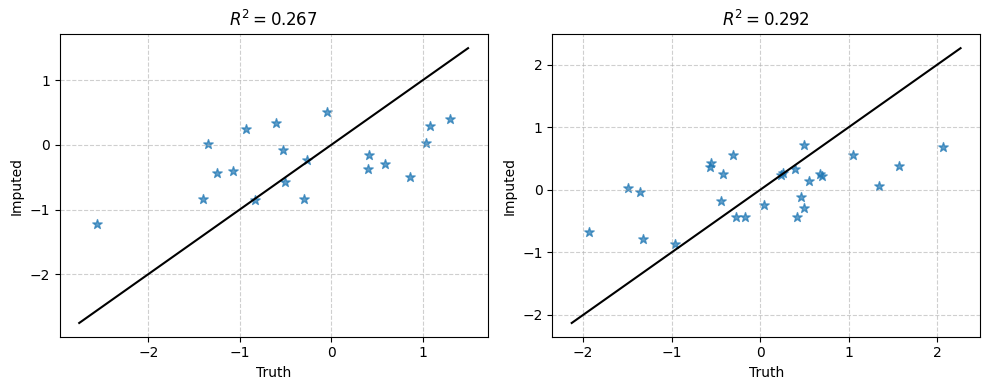

In [10]:
from sklearn.metrics import r2_score

def plot_imputation_grid(X_true, X_imputed, mask_missing):
    N, D = X_true.shape
    # Calculate grid size (e.g., for 4 features, 2x2; for 2 features, 1x2)
    cols = 2
    rows = (D + 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows))
    axes = axes.flatten() # Flatten to iterate easily

    for d in range(D):
        # Extract only the values that were originally missing
        idx = mask_missing[:, d]
        y_true = X_true[idx, d]
        y_pred = X_imputed[idx, d]
        
        # Calculate R^2
        r2 = r2_score(y_true, y_pred)
        
        # Scatter plot
        axes[d].scatter(y_true, y_pred, marker='*', s=50, alpha=0.7, label='Imputed')
        
        # Identity line (Truth = Imputed)
        lo, hi = axes[d].get_xlim()
        axes[d].plot([lo, hi], [lo, hi], color='black', linewidth=1.5)
        
        axes[d].set_title(f"$R^2 = {r2:.3f}$")
        axes[d].set_xlabel("Truth")
        axes[d].set_ylabel("Imputed")
        axes[d].grid(True, linestyle='--', alpha=0.6)

    # Hide unused axes if D is odd
    for i in range(D, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# --- To Run ---
mask = np.isnan(X_missing)
plot_imputation_grid(X, X_imputed, mask)

# compare with the imputing using true parameters (mean and covariance from the original data)
mu_true = np.array([0, 0])
cov_true = np.array([[1, 0.5], [0.5, 1]])

X_imputed_true_params = impute_missing_data(X_missing, mu_true, cov_true)
print("Imputed Data using True Parameters (first 5 rows):\n", X_imputed_true_params[:5])

# plot imputation grid for true parameters
plot_imputation_grid(X, X_imputed_true_params, mask)